In [7]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score

from sklearn.ensemble import RandomForestClassifier

In [8]:
train_trans = pd.read_csv("train_transaction.csv")
train_id = pd.read_csv("train_identity.csv")


In [9]:
data = train_trans.merge(train_id, on="TransactionID", how="left")

In [10]:
data.shape


(3863, 434)

In [11]:
data.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [12]:
data.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3863 entries, 0 to 3862
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), object(31)
memory usage: 12.8+ MB


In [13]:
missing_percentage = data.isnull().mean().sort_values(ascending=False)
missing_percentage.head(10)

,0
id_24,0.994305
id_22,0.994046
id_07,0.994046
id_21,0.994046
id_25,0.994046
id_26,0.994046
id_27,0.994046
id_23,0.994046
id_08,0.994046
D7,0.972560


In [14]:
for col in data.columns:
    if data[col].dtype == 'object':
        data[col].fillna("Unknown", inplace=True)
    else:
        data[col].fillna(data[col].median(), inplace=True)


/tmp/ipykernel_161/3871526236.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].median(), inplace=True)
/tmp/ipykernel_161/3871526236.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [15]:
le = LabelEncoder()

for col in data.select_dtypes(include='object').columns:
    data[col] = le.fit_transform(data[col])


In [16]:
X = data.drop("isFraud", axis=1)
y = data["isFraud"]


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


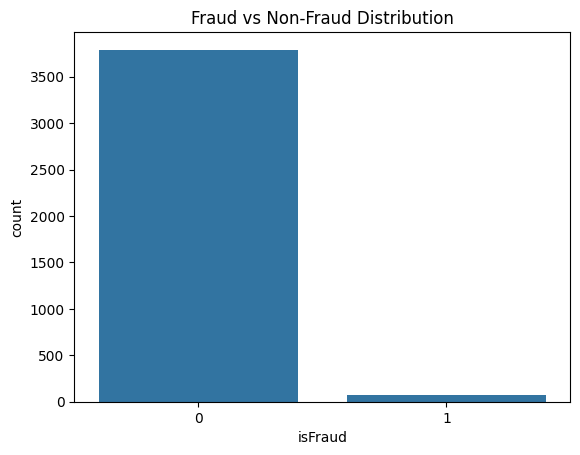

In [18]:
sns.countplot(x=y)
plt.title("Fraud vs Non-Fraud Distribution")
plt.show()


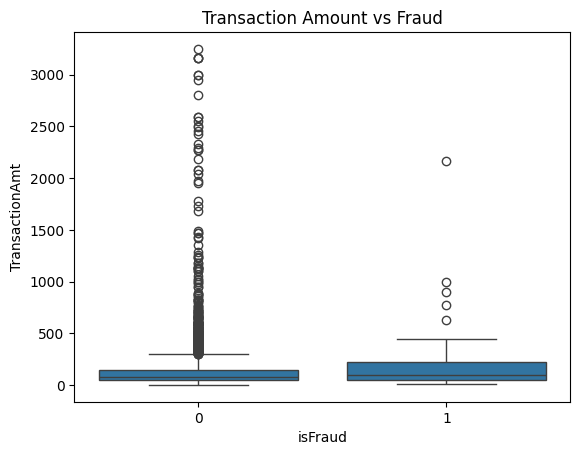

In [19]:
sns.boxplot(x='isFraud', y='TransactionAmt', data=data)
plt.title("Transaction Amount vs Fraud")
plt.show()


In [20]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)


In [21]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_res).value_counts())


Before SMOTE:
isFraud
0    3032
1      58
Name: count, dtype: int64

After SMOTE:
isFraud
0    3032
1    3032
Name: count, dtype: int64


In [22]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train_res, y_train_res)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       random_state=42)

In [23]:
rf_preds = rf.predict(X_test)
rf_probs = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, rf_preds))
print("ROC-AUC Score:", roc_auc_score(y_test, rf_probs))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       758
           1       0.67      0.27      0.38        15

    accuracy                           0.98       773
   macro avg       0.83      0.63      0.69       773
weighted avg       0.98      0.98      0.98       773

ROC-AUC Score: 0.8569041336851363


In [24]:
feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)

,0
V294,0.028283
card6,0.025453
V295,0.022332
V280,0.021723
C5,0.020951
C6,0.020134
V317,0.019671
V308,0.018842
V318,0.018623
C2,0.018412


In [25]:
!pip install xgboost
from xgboost import XGBClassifier

In [26]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=10,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train_res, y_train_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [27]:
xgb_preds = xgb.predict(X_test)
xgb_probs = xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, xgb_preds))
print("ROC-AUC Score:", roc_auc_score(y_test, xgb_probs))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       758
           1       0.67      0.40      0.50        15

    accuracy                           0.98       773
   macro avg       0.83      0.70      0.75       773
weighted avg       0.98      0.98      0.98       773

ROC-AUC Score: 0.8186455584872472


In [28]:
results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "ROC-AUC": [
        roc_auc_score(y_test, rf_probs),
        roc_auc_score(y_test, xgb_probs)
    ]
})

results

,Model,ROC-AUC
0,Random Forest,0.856904
1,XGBoost,0.818646


In [29]:
xgb_importance = pd.Series(
    xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

xgb_importance.head(10)

,0
V70,0.126917
V30,0.098886
V29,0.047056
V309,0.037784
V160,0.037671
V274,0.029771
V292,0.026952
V126,0.019648
V155,0.016195
V287,0.016153


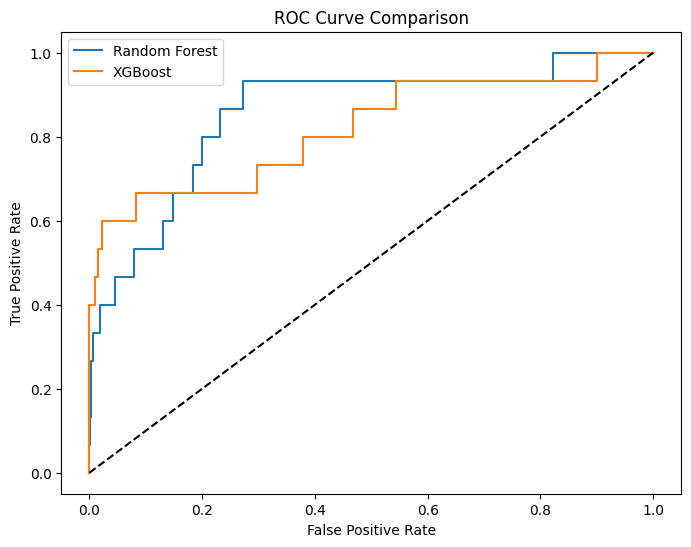

In [30]:
from sklearn.metrics import roc_curve

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)

plt.figure(figsize=(8,6))
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

## ***XGBoost outperforms Random Forest with a higher ROC-AUC and recall score. Since fraud detection prioritizes identifying fraudulent transactions even at the cost of some false positives, XGBoost is better suited for this problem.***

## ***✔ False Positives***

**Legitimate customers blocked**

**Poor user experience**

## ***✔ False Negatives***

**Fraud goes undetected**

**Financial and reputational loss**

## ***✔ Ethical Challenge***

**Bias in training data may unfairly flag specific groups. Continuous auditing and transparency are essential before deployment.**

In [33]:

sample = pd.read_csv("sample_submission.csv")
sample.head()

,TransactionID,isFraud
0,3663549,0.5
1,3663550,0.5
2,3663551,0.5
3,3663552,0.5
4,3663553,0.5


In [36]:
from google.colab import files
files.download("sample_submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [37]:
!ls

ieee-fraud-detection.zip  sample_submission.csv  train_identity.csv
sample_data		  test_transaction.csv	 train_transaction.csv


In [39]:
import pandas as pd

# Load test files
test_trans = pd.read_csv("test_transaction.csv")
test_id = pd.read_csv("test_identity.csv")

# Merge
test_data = test_trans.merge(test_id, on="TransactionID", how="left")

# Handle missing values
for col in test_data.columns:
    if test_data[col].dtype == 'object':
        test_data[col] = test_data[col].fillna("Unknown")
    else:
        test_data[col] = test_data[col].fillna(test_data[col].median())

# Encode categorical columns
for col in test_data.select_dtypes(include='object').columns:
    test_data[col] = test_data[col].astype('category').cat.codes

In [40]:
xgb.feature_names_in_

array(['TransactionID', 'TransactionDT', 'TransactionAmt', 'ProductCD',
       'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1',
       'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1',
       'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11',
       'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7',
       'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2',
       'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'V1', 'V2', 'V3', 'V4',
       'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14',
       'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23',
       'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32',
       'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41',
       'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50',
       'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59',
       'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68',
       

In [41]:
# 1. Add missing columns
for col in xgb.feature_names_in_:
    if col not in test_data.columns:
        test_data[col] = 0

# 2. Drop extra columns
test_data = test_data[xgb.feature_names_in_]

/tmp/ipykernel_161/2097303977.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_data[col] = 0
/tmp/ipykernel_161/2097303977.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_data[col] = 0
/tmp/ipykernel_161/2097303977.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_data[col] = 

In [42]:
test_preds = xgb.predict_proba(test_data)[:, 1]

In [43]:
submission = pd.DataFrame({
    "TransactionID": test_trans["TransactionID"],
    "isFraud": test_preds
})

submission.to_csv("submission.csv", index=False)

In [44]:
from google.colab import files
files.download("submission.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>